# Week 7 Laboratory
# Task 1: Text Feature Extraction and Document Classification using Naïve Bayes

---

## Learning Objectives

After completing this laboratory, you should be able to:

✓ Load and explore the **20 Newsgroups** text dataset directly via `sklearn.datasets.fetch_20newsgroups`.

✓ Preprocess raw text documents by removing punctuation, digits, short tokens, and grammatical stopwords.

✓ Understand and visualize **Zipf's Law** to construct a fixed vocabulary ($|V| = 5,000$).

✓ Extract **Bag-of-Words (Vector Space Model)** document-term frequency count representations.

✓ Train and evaluate Scikit-Learn's `MultinomialNB` classifier using Accuracy, Macro Precision, Recall, F1-score, and a Confusion Matrix.

✓ Implement a **Multinomial Naïve Bayes Classifier with Laplace Smoothing (alpha=1) from scratch** using vectorized NumPy operations in log-space.

✓ Verify numerical equivalence and benchmark inference latency between custom and Scikit-Learn models.

✓ Interpret model predictions by extracting the top distinctive keywords for various newsgroup categories.


---
## Setup Environment

Install necessary packages to run this notebook.


In [1]:
!pip install numpy matplotlib scikit-learn seaborn tqdm


---
## 1. Imports & Pre-defined Helper Functions

We import required libraries and provide helper utilities for text processing and inspection:
* `STOPWORDS`: Standard collection of English stop words to filter out non-informative words.
* `timer`: High-resolution benchmark timer.
* `fetch_20newsgroups`: Built-in scikit-learn dataset loader.


In [2]:
import os
import string
import collections
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from timeit import default_timer as timer

from sklearn.datasets import fetch_20newsgroups
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Standard English Stopwords List
STOPWORDS = set("""
    a about above after again against all am an and any are arent as at
    be because been before being below between both but by can cannot could
    couldnt did didnt do does doesnt doing dont down during each few for
    from further had hadnt has hasnt have havent having he hed hell hes
    her here heres hers herself him himself his how hows i id ill im
    ive if in into is isnt it its itself lets me more most mustnt
    my myself no nor not of off on once only or other ought our ours
    ourselves out over own same shant she shed shell shes should shouldnt
    so some such than that thats the their theirs them themselves then there
    theres these they theyd theyll theyre theyve this those through to too
    under until up very was wasnt we wed well were werent
    what whats when whens where wheres which while who whos whom why whys
    with wont would wouldnt you youd youll youre youve your yours yourself
    yourselves re subject writes article organization lines nntppostinghost university
""".split())

print("Environment set up successfully!")


Environment set up successfully!


---
## STEP 1. Load Dataset directly from Scikit-Learn (`fetch_20newsgroups`)

The **20 Newsgroups** dataset is a classic benchmark in Natural Language Processing and Text Classification, comprising ~18,000 Usenet posts across 20 diverse discussion topics (computing, science, recreation, politics, religion).

We fetch the dataset directly using `sklearn.datasets.fetch_20newsgroups`. Scikit-Learn provides built-in `subset='train'` and `subset='test'` splits.

### Task:
1. Load the training partition using `fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))`.
2. Load the test partition using `fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))`.
3. Print the number of training and test documents along with all 20 target categories.


In [3]:
# STEP 1. Load dataset directly from scikit-learn
print("Fetching 20 Newsgroups dataset from scikit-learn...")
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), random_state=42)

# Extract raw texts and numerical labels
raw_train_docs = newsgroups_train.data
y_train = newsgroups_train.target
raw_test_docs = newsgroups_test.data
y_test = newsgroups_test.target
target_names = newsgroups_train.target_names

print(f"Loaded {len(raw_train_docs)} training documents.")
print(f"Loaded {len(raw_test_docs)} test documents.")
print(f"Total Categories ({len(target_names)}):\n{target_names}")


Fetching 20 Newsgroups dataset from scikit-learn...
Loaded 11314 training documents.
Loaded 7532 test documents.
Total Categories (20):
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


---
## STEP 2. Inspect Raw Document Samples

Before preprocessing, let us inspect what raw newsgroup posts look like.

### Task:
Define a helper function `show_sample_document()` to display raw posts from any category.


In [4]:
def show_sample_document(category_name='sci.space', doc_idx=0, max_lines=15):
    """Display a raw sample document for a given newsgroup category."""
    cat_id = target_names.index(category_name)
    matching_indices = [i for i, target in enumerate(y_train) if target == cat_id]
    
    if not matching_indices:
        print(f"No documents found for category: {category_name}")
        return
        
    doc = raw_train_docs[matching_indices[doc_idx % len(matching_indices)]]
    lines = doc.strip().split('\n')
    
    print('=' * 80)
    print(f" Category   : {category_name} (Class ID: {cat_id})")
    print(f" Sample #   : {doc_idx + 1} of {len(matching_indices)} in category")
    print(f" Total Lines: {len(lines)} | Total Characters: {len(doc)}")
    print('=' * 80)
    
    preview = lines[:max_lines]
    print('\n'.join(preview))
    if len(lines) > max_lines:
        print(f"\n... [Truncated: showing first {max_lines} of {len(lines)} lines] ...")
    print('=' * 80)

# Inspect sample documents from selected categories
show_sample_document(category_name='sci.space', doc_idx=0)
print()
show_sample_document(category_name='rec.sport.hockey', doc_idx=0)


 Category   : sci.space (Class ID: 14)
 Sample #   : 1 of 593 in category
 Total Lines: 9 | Total Characters: 448
From article <C5owCB.n3p@world.std.com>, by tombaker@world.std.com (Tom A Baker):


My understanding is that the 'expected errors' are basically
known bugs in the warning system software - things are checked
that don't have the right values in yet because they aren't
set till after launch, and suchlike. Rather than fix the code
and possibly introduce new bugs, they just tell the crew
'ok, if you see a warning no. 213 before liftoff, ignore it'.

 Category   : rec.sport.hockey (Class ID: 10)
 Sample #   : 1 of 600 in category
 Total Lines: 10 | Total Characters: 496
I think that Mike Foligno was the captain of the Sabres when he
got traded to the Leafs. Also, wasn't Rick Vaive the captain of
the Leafs when he got traded to Chicago (with Steve Thomas for
Ed Olcyzk and someone). Speaking of the Leafs, I believe that
Darryl Sittler was their captain (he'd torn the "C" off his
j

---
## STEP 3. Text Preprocessing & Tokenization

Raw natural language documents contain punctuation, numbers, casing inconsistencies, and uninformative stopwords.

Our preprocessing pipeline performs:
1. **Punctuation & Digit Removal**: Strip all punctuation and numerical digits.
2. **Lowercasing & Splitting**: Normalize all characters to lowercase and split by whitespace into words.
3. **Stopword & Short-Token Filtering**: Remove words in `STOPWORDS` and any word of length $\le 2$.

### Task:
Implement `clean_and_tokenize()` and preprocess all training and test documents.


In [5]:
# Translation table to remove punctuation and numbers efficiently
cleanup_table = str.maketrans('', '', string.punctuation + string.digits)

def clean_and_tokenize(text):
    """Normalize raw text, strip punctuation/digits, filter stopwords, and return token list."""
    if not isinstance(text, str):
        return []
    
    # 1. Remove punctuation and digits, convert to lowercase
    cleaned = text.translate(cleanup_table).lower()
    
    # 2. Tokenize and filter stopwords / short tokens (length <= 2)
    tokens = [
        word for word in cleaned.split()
        if len(word) > 2 and word not in STOPWORDS
    ]
    return tokens

# Clean and tokenize all training documents
print("Tokenizing training documents...")
train_tokens_list = [clean_and_tokenize(doc) for doc in tqdm(raw_train_docs, desc="Train Docs")]

# Clean and tokenize all test documents
print("Tokenizing test documents...")
test_tokens_list = [clean_and_tokenize(doc) for doc in tqdm(raw_test_docs, desc="Test Docs")]

print(f"\nTokenized {len(train_tokens_list)} train documents and {len(test_tokens_list)} test documents.")
print(f"Sample tokens from doc 0: {train_tokens_list[0][:12]}")


Tokenizing training documents...


Train Docs: 100%|██████████| 11314/11314 [00:00<00:00, 47427.80it/s]


Tokenizing test documents...


Test Docs: 100%|██████████| 7532/7532 [00:00<00:00, 65976.44it/s]


Tokenized 11314 train documents and 7532 test documents.
Sample tokens from doc 0: ['wondering', 'anyone', 'enlighten', 'car', 'saw', 'day', 'door', 'sports', 'car', 'looked', 'late', 'early']


---
## STEP 4. Vocabulary Selection & Frequency Analysis (Zipf's Law)

We construct a fixed feature vocabulary by counting word frequencies across the entire training corpus.

According to **Zipf's Law**, the frequency of any word is inversely proportional to its rank in the frequency table:
$$f(w) \propto \frac{1}{\text{rank}(w)}$$

### Task:
1. Count token frequencies across the training set using `collections.Counter`.
2. Select the top $N = 5,000$ most frequent words as the feature vocabulary $V$.
3. Build a fast `vocab_index` dictionary mapping each word to an index $0 \dots 4999$.
4. Visualize the rank-frequency distribution curve.


In [7]:
# Count word frequencies across the training corpus
vocab_counter = collections.Counter()
for tokens in train_tokens_list:
    vocab_counter.update(tokens)

print(f"Total unique words in training set: {len(vocab_counter):,}")

# Select Top N feature words
VOCAB_SIZE = 5000
most_common_words = vocab_counter.most_common(VOCAB_SIZE)
vocabulary = [word for word, count in most_common_words]
vocab_index = {word: idx for idx, word in enumerate(vocabulary)}

print(f"Selected Top {VOCAB_SIZE} words as feature vocabulary.")
print(f"Top 15 most frequent words: {[w for w, _ in most_common_words[:15]]}")


Total unique words in training set: 90,946
Selected Top 5000 words as feature vocabulary.
Top 15 most frequent words: ['will', 'one', 'people', 'like', 'just', 'get', 'know', 'also', 'maxaxaxaxaxaxaxaxaxaxaxaxaxaxax', 'use', 'think', 'time', 'new', 'good', 'may']


Let's visualize the word frequency drop-off to observe Zipf's Law.


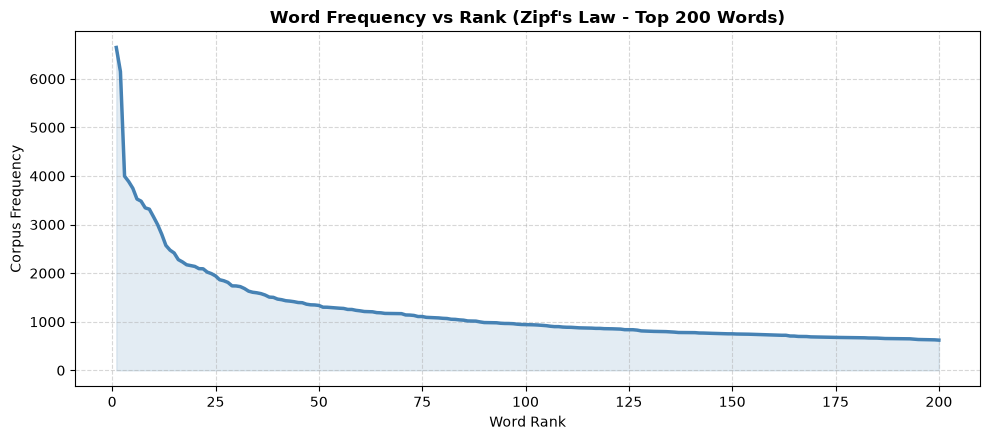

In [8]:
# Plot word frequency distribution (Top 200 Words)
counts_sorted = [count for _, count in vocab_counter.most_common(200)]

plt.figure(figsize=(10, 4.5))
plt.plot(range(1, len(counts_sorted) + 1), counts_sorted, color='steelblue', lw=2.5)
plt.fill_between(range(1, len(counts_sorted) + 1), counts_sorted, color='steelblue', alpha=0.15)
plt.title("Word Frequency vs Rank (Zipf's Law - Top 200 Words)", fontsize=12, fontweight='bold')
plt.xlabel("Word Rank", fontsize=10)
plt.ylabel("Corpus Frequency", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---
## STEP 5. Feature Extraction: Bag-of-Words (Vector Space Model)

Each document $d_i$ is represented as a Term-Frequency (TF) count vector $\mathbf{x}_i \in \mathbb{R}^{|V|}$, where $|V| = 5,000$:
$$\mathbf{x}_i = [\text{TF}(w_1, d_i), \text{TF}(w_2, d_i), \dots, \text{TF}(w_{|V|}, d_i)]$$

### Task:
Implement `build_feature_matrix()` to convert tokenized documents into 2D NumPy Document-Term count matrices $X_{train}$ and $X_{test}$.


In [20]:
def build_feature_matrix(tokens_list, vocab_map, vocab_size):
    """Construct a 2D numpy count matrix (Document-Term Matrix)."""
    X = np.zeros((len(tokens_list), vocab_size), dtype=np.float32)
    for row_idx, tokens in enumerate(tokens_list):
        doc_counts = collections.Counter(tokens)
        for word, count in doc_counts.items():
            if word in vocab_map:
                X[row_idx, vocab_map[word]] = count
    return X

# Build Document-Term count matrices
print("Building feature matrices...")
X_train = build_feature_matrix(train_tokens_list, vocab_index, VOCAB_SIZE)
X_test = build_feature_matrix(test_tokens_list, vocab_index, VOCAB_SIZE)

y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

print(f"X_train shape: {X_train.shape} (dtype: {X_train.dtype})")
print(f"X_test shape : {X_test.shape} (dtype: {X_test.dtype})")
print(f"Sparsity     : {100.0 * (1.0 - np.count_nonzero(X_train) / X_train.size):.2f}% zero entries")

# X_train[0].nonzero()
# y_train_arr[0]

Building feature matrices...
X_train shape: (11314, 5000) (dtype: float32)
X_test shape : (7532, 5000) (dtype: float32)
Sparsity     : 99.08% zero entries


---
## STEP 6. Text Classification with Scikit-Learn `MultinomialNB`

We train `sklearn.naive_bayes.MultinomialNB` on $(X_{train}, y_{train})$ and evaluate performance on the held-out test set $(X_{test}, y_{test})$.

### Task:
1. Fit `MultinomialNB(alpha=1.0)`.
2. Measure training time and test inference latency.
3. Report Accuracy, Macro Precision, Recall, F1-Score, and plot the Confusion Matrix.


In [10]:
# STEP 6. Train Scikit-Learn MultinomialNB
sklearn_nb = MultinomialNB(alpha=1.0)

start_train = timer()
sklearn_nb.fit(X_train, y_train_arr)
train_time_sklearn = timer() - start_train

start_test = timer()
y_pred_sklearn = sklearn_nb.predict(X_test)
test_time_sklearn = timer() - start_test

sklearn_acc = accuracy_score(y_test_arr, y_pred_sklearn)
sklearn_prec = precision_score(y_test_arr, y_pred_sklearn, average='macro')
sklearn_rec = recall_score(y_test_arr, y_pred_sklearn, average='macro')
sklearn_f1 = f1_score(y_test_arr, y_pred_sklearn, average='macro')

print(f"Training time   : {train_time_sklearn:.4f} s")
print(f"Inference time  : {test_time_sklearn:.4f} s ({(test_time_sklearn / len(X_test)) * 1000:.3f} ms/doc)")
print(f"Test Accuracy   : {sklearn_acc * 100:.2f}%")
print(f"Macro Precision : {sklearn_prec * 100:.2f}%")
print(f"Macro Recall    : {sklearn_rec * 100:.2f}%")
print(f"Macro F1-Score  : {sklearn_f1 * 100:.2f}%\n")

print("Classification Report (Scikit-Learn MultinomialNB):")
print(classification_report(y_test_arr, y_pred_sklearn, target_names=target_names, digits=4))


Training time   : 0.1757 s
Inference time  : 0.0577 s (0.008 ms/doc)
Test Accuracy   : 60.45%
Macro Precision : 60.41%
Macro Recall    : 59.34%
Macro F1-Score  : 59.27%

Classification Report (Scikit-Learn MultinomialNB):
                          precision    recall  f1-score   support

             alt.atheism     0.4094    0.4890    0.4457       319
           comp.graphics     0.5051    0.6401    0.5646       389
 comp.os.ms-windows.misc     0.6336    0.4213    0.5061       394
comp.sys.ibm.pc.hardware     0.5352    0.5434    0.5392       392
   comp.sys.mac.hardware     0.5264    0.5948    0.5585       385
          comp.windows.x     0.7264    0.6051    0.6602       395
            misc.forsale     0.7453    0.7128    0.7287       390
               rec.autos     0.6383    0.6641    0.6510       396
         rec.motorcycles     0.6111    0.6910    0.6486       398
      rec.sport.baseball     0.7537    0.7783    0.7658       397
        rec.sport.hockey     0.5409    0.8120    0.

Let's display the Confusion Matrix across all 20 newsgroups.


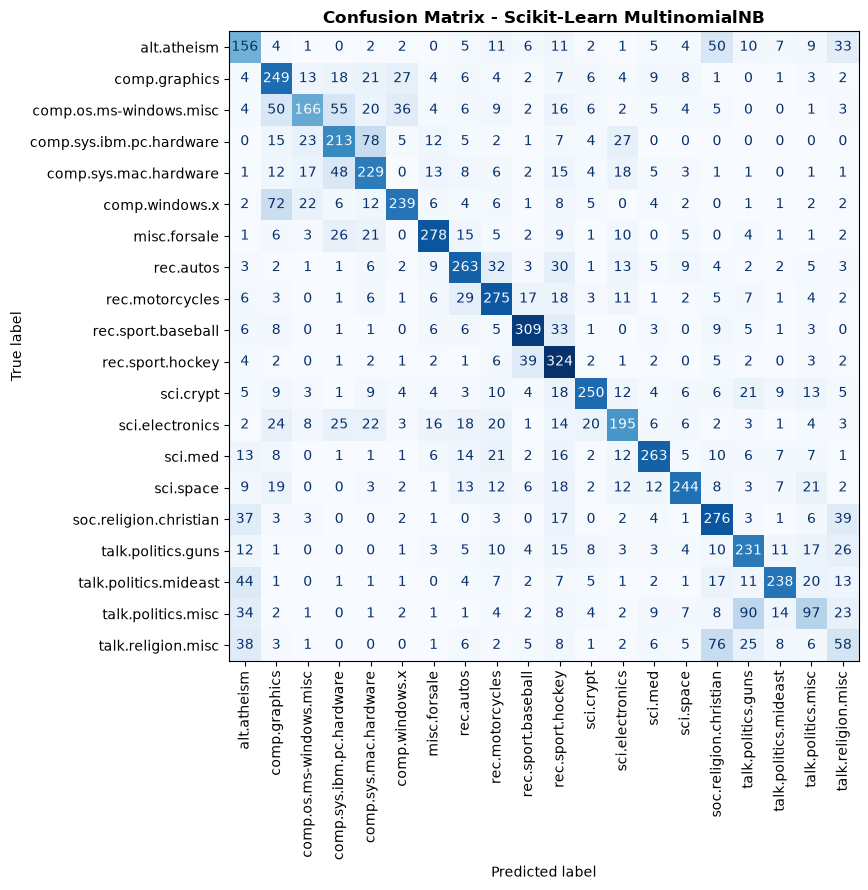

In [11]:
# Plot Confusion Matrix for Scikit-Learn model
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test_arr, 
    y_pred_sklearn, 
    display_labels=target_names, 
    xticks_rotation=90, 
    cmap='Blues', 
    ax=ax,
    colorbar=False
)
plt.title('Confusion Matrix - Scikit-Learn MultinomialNB', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## STEP 7. Implement Multinomial Naïve Bayes from Scratch

### Mathematical Formulation:

Given a document $\mathbf{x} = (x_1, x_2, \dots, x_{|V|})$, we classify $\mathbf{x}$ by finding the class $\hat{c}$ that maximizes the posterior probability (**Maximum A Posteriori / MAP**):

$$\hat{c} = \arg\max_{c} P(c \mid \mathbf{x}) = \arg\max_{c} \left[ P(c) \prod_{j=1}^{|V|} P(w_j \mid c)^{x_j} \right]$$

To prevent numerical underflow with small probabilities, we operate entirely in **log-space**:

$$\hat{c} = \arg\max_{c} \left[ \log P(c) + \sum_{j=1}^{|V|} x_j \log P(w_j \mid c) \right]$$

1. **Class Prior Probability:**
$$P(c) = \frac{N_c}{N_{\text{total}}}$$
where $N_c$ is the number of training documents in class $c$.

2. **Word Likelihood with Laplace Smoothing ($\alpha = 1$):**
$$P(w_j \mid c) = \frac{\text{count}(w_j, c) + \alpha}{\sum_{k=1}^{|V|} \text{count}(w_k, c) + \alpha |V|}$$
where $\text{count}(w_j, c)$ is the total occurrences of word $w_j$ in class $c$, and $|V|$ is the vocabulary size.

### Task:
Implement `CustomMultinomialNB` with `fit()` and `predict()` methods using vectorized matrix multiplication:
$$\text{Log-Posterior Matrix} = \mathbf{b}_{\text{prior}} + X \cdot W_{\text{likelihood}}^T$$


In [12]:
class CustomMultinomialNB:
    """
    Multinomial Naïve Bayes Classifier with Laplace Smoothing implemented from scratch.
    """
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes_ = None
        self.log_class_priors_ = None
        self.log_feature_likelihoods_ = None
        
    def fit(self, X, y):
        """
        Learn log class priors and Laplace-smoothed log feature likelihoods from training data.
        
        Parameters:
            X: np.ndarray of shape (n_samples, n_features) - Document-term count matrix
            y: np.ndarray of shape (n_samples,) - Integer class labels
        """
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        self.log_class_priors_ = np.zeros(n_classes, dtype=np.float64)
        self.log_feature_likelihoods_ = np.zeros((n_classes, n_features), dtype=np.float64)
        
        for idx, c in enumerate(self.classes_):
            # Select all document feature vectors belonging to class c
            X_c = X[y == c]
            
            # 1. Class Prior: P(c) = N_c / N_total
            self.log_class_priors_[idx] = np.log(len(X_c) / n_samples)
            
            # 2. Total count of word j in class c
            word_counts_in_c = X_c.sum(axis=0)
            
            # 3. Total word tokens across all documents in class c
            total_tokens_in_c = word_counts_in_c.sum()
            
            # 4. Laplace-smoothed Likelihood: (count(w, c) + alpha) / (total_tokens + alpha * |V|)
            smoothed_likelihood = (word_counts_in_c + self.alpha) / (total_tokens_in_c + self.alpha * n_features)
            self.log_feature_likelihoods_[idx] = np.log(smoothed_likelihood)
            
        return self
        
    def predict(self, X):
        """
        Compute posterior log-score per class and predict argmax class:
        log P(c | d) ∝ log P(c) + sum_j x_j * log P(w_j | c)
        
        Parameters:
            X: np.ndarray of shape (n_samples, n_features)
        Returns:
            predictions: np.ndarray of shape (n_samples,)
        """
        # Vectorized calculation: (n_samples, n_classes) = (1, n_classes) + (n_samples, n_features) @ (n_features, n_classes)
        log_posteriors = self.log_class_priors_ + (X @ self.log_feature_likelihoods_.T)
        best_class_indices = np.argmax(log_posteriors, axis=1)
        return self.classes_[best_class_indices]

# Fit and benchmark the custom MultinomialNB model
custom_nb = CustomMultinomialNB(alpha=1.0)

start_train = timer()
custom_nb.fit(X_train, y_train_arr)
train_time_custom = timer() - start_train

start_test = timer()
y_pred_custom = custom_nb.predict(X_test)
test_time_custom = timer() - start_test

custom_acc = accuracy_score(y_test_arr, y_pred_custom)
print(f"Custom Model Training time : {train_time_custom:.4f} s")
print(f"Custom Model Inference time: {test_time_custom:.4f} s ({(test_time_custom / len(X_test)) * 1000:.3f} ms/doc)")
print(f"Custom Model Test Accuracy : {custom_acc * 100:.2f}%")


Custom Model Training time : 0.0454 s
Custom Model Inference time: 0.0903 s (0.012 ms/doc)
Custom Model Test Accuracy : 60.45%


---
## STEP 8. Performance Comparison: Custom vs Scikit-Learn

We quantitatively compare our from-scratch implementation against Scikit-Learn's official `MultinomialNB` implementation.

### Task:
1. Compute Accuracy, Macro Precision, Macro Recall, and Macro F1-Score for both models.
2. Display a formatted comparison table.
3. Compute the **Prediction Agreement Rate** ($\%$) across all test instances.


In [13]:
# 1. Compute evaluation metrics
metrics_sklearn = {
    'Test Accuracy': accuracy_score(y_test_arr, y_pred_sklearn) * 100,
    'Macro Precision': precision_score(y_test_arr, y_pred_sklearn, average='macro') * 100,
    'Macro Recall': recall_score(y_test_arr, y_pred_sklearn, average='macro') * 100,
    'Macro F1-Score': f1_score(y_test_arr, y_pred_sklearn, average='macro') * 100,
}

metrics_custom = {
    'Test Accuracy': accuracy_score(y_test_arr, y_pred_custom) * 100,
    'Macro Precision': precision_score(y_test_arr, y_pred_custom, average='macro') * 100,
    'Macro Recall': recall_score(y_test_arr, y_pred_custom, average='macro') * 100,
    'Macro F1-Score': f1_score(y_test_arr, y_pred_custom, average='macro') * 100,
}

# 2. Print formatted comparison table
print('=' * 62)
print(f"{'Metric':<22} | {'Scikit-Learn MNB':>16} | {'Custom MNB':>16}")
print('-' * 62)
for metric in metrics_sklearn:
    sk_val = f"{metrics_sklearn[metric]:.2f}%"
    cu_val = f"{metrics_custom[metric]:.2f}%"
    print(f"{metric:<22} | {sk_val:>16} | {cu_val:>16}")
print('=' * 62)

# 3. Check prediction agreement rate between models
match_rate = np.mean(y_pred_sklearn == y_pred_custom) * 100
print(f"\nPrediction Agreement Rate between Custom and Scikit-Learn: {match_rate:.2f}%")


Metric                 | Scikit-Learn MNB |       Custom MNB
--------------------------------------------------------------
Test Accuracy          |           60.45% |           60.45%
Macro Precision        |           60.41% |           60.41%
Macro Recall           |           59.34% |           59.34%
Macro F1-Score         |           59.27% |           59.27%

Prediction Agreement Rate between Custom and Scikit-Learn: 100.00%


---
## STEP 9. Model Interpretability: Top Keywords per Category

A key strength of Naïve Bayes is its clear interpretability. By inspecting the highest conditional log-likelihood values $\log P(w_j \mid c)$, we can reveal the most characteristic vocabulary words for each category.

### Task:
Extract and display the top 10 highest-likelihood words for selected newsgroup categories.


In [14]:
# Inspect top distinctive words for representative categories
sample_categories = [
    'comp.graphics', 
    'rec.sport.hockey', 
    'sci.space', 
    'talk.politics.mideast',
    'sci.med',
    'soc.religion.christian'
]

print("Top 10 Most Characteristic Words per Category:\n")
for cat_name in sample_categories:
    cat_idx = target_names.index(cat_name)
    log_probs = custom_nb.log_feature_likelihoods_[cat_idx]
    
    # Sort word indices by log-likelihood in descending order
    top_indices = np.argsort(log_probs)[::-1][:10]
    top_words = [vocabulary[i] for i in top_indices]
    
    print(f"➤ {cat_name:<24}: {', '.join(top_words)}")


Top 10 Most Characteristic Words per Category:

➤ comp.graphics           : image, will, graphics, file, also, jpeg, use, files, data, software
➤ rec.sport.hockey        : team, will, game, hockey, play, season, games, period, one, nhl
➤ sci.space               : space, will, one, nasa, launch, also, like, data, just, time
➤ talk.politics.mideast   : people, one, armenian, said, armenians, turkish, israel, will, jews, know
➤ sci.med                 : one, will, also, people, use, get, medical, health, know, like
➤ soc.religion.christian  : god, one, will, jesus, people, church, think, know, believe, just


---
## Reflection Questions

1. **Q1 (Underflow Prevention):** Why do we compute sums of log-probabilities $\log P(c) + \sum x_j \log P(w_j \mid c)$ rather than multiplying raw probabilities $P(c) \prod P(w_j \mid c)^{x_j}$?

2. **Q2 (Zero-Frequency Problem & Laplace Smoothing):** What happens to the document likelihood if a test word never appeared in class $c$ during training without Laplace smoothing? Why is $|V|$ added to the denominator when $\alpha = 1$?

3. **Q3 (Feature Representation):** What is the fundamental difference between the **Term Frequency (Multinomial)** model and the **Binary (Bernoulli)** model in text classification?

4. **Q4 (Independence Assumption):** Naïve Bayes assumes words are conditionally independent given the class (e.g., "machine" and "learning" are treated independently). Why does Naïve Bayes often perform remarkably well in practice despite this unrealistic assumption?
